# 微调与适配：ControlNet、LoRA 与 DreamBooth

> **难易：** 上 | **所需时辰：** 约三刻

预训练之扩散模型乃通用之图像生成器。然若需模型*唯*绘某品牌之画风，或恒生某特定角色，或听从边缘图、深度图之指引，则非微调不可 —— 此中工程抉择，决定成果为惊艳抑或灾难。

此篇述三大微调范式 —— **ControlNet**、**LoRA** 与 **DreamBooth** —— 兼及数据管道与故障模式，辨周末之实验与生产之模型之分际。

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import math

import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "../../..")))

from mp_tutorial.formatting import info_box
from mp_tutorial.plantuml import render_plantuml
import warnings
warnings.filterwarnings("ignore", message="Glyph.*missing from font", category=UserWarning)

## 一、何以微调？

如 Stable Diffusion 等基础扩散模型，训于数十亿图文对上。几乎无所不能生 —— 然乃**通用**之器。微调使之专精：

- **一致之角色**：于多姿态、多场景生同一角色
- **特定画风**：强制视觉风格（动漫、水彩、品牌形象）
- **可控布局**：以空间输入为条件，如边缘图、深度图、人体姿态

大略有三途径：

| 途径 | 代价 | 例 |
|----------|------|--------|
| 全量微调 | 昂贵（1-8 GPU，数日） | 重训整个 UNet |
| 适配器法 | 高效（1 GPU，数时辰） | LoRA、Textual Inversion |
| 架构扩展 | 适中（1 GPU，一日） | ControlNet、IP-Adapter |

In [2]:
info_box(
    "全量微调 Stable Diffusion 模型须 1-8 GPU 及数日训练。"
    "适配器法如 LoRA 以单 GPU 数时辰可达相近之效。",
    title="微调之代价"
)


## 二、ControlNet 之架构

### 所遇之难

欲以空间输入 —— 边缘图、人体姿态、深度图 —— 为图像生成之**条件**。然基础模型仅受文本提示。如何增新之输入模态而不毁模型已有之知？

### 解法

**ControlNet**（Zhang 等，2023）复制 UNet 之编码半部，以**零初始化卷积**接之于原解码器。基础模型完全冻结。训练伊始，零卷积输出皆零，故 ControlNet 对基础模型*无任何影响*。训练渐教之注入空间信息。

In [3]:
render_plantuml("""
@startuml
skinparam backgroundColor white
rectangle "Frozen UNet" as unet {
  rectangle "Encoder" as enc
  rectangle "Decoder" as dec
}
rectangle "ControlNet\n(Trainable Copy)" as ctrl {
  rectangle "Encoder Copy" as enc_copy
  rectangle "Zero Conv" as zc
}
rectangle "Condition\n(Edge/Pose/Depth)" as cond

cond --> enc_copy
enc_copy --> zc
zc --> dec : "add to skip connections"
enc --> dec
@enduml
""")

**PlantUML rendering failed** (not well-formed (invalid token): line 34, column 16). Source:
```
@startuml
skinparam backgroundColor white
rectangle "Frozen UNet" as unet {
  rectangle "Encoder" as enc
  rectangle "Decoder" as dec
}
rectangle "ControlNet
(Trainable Copy)" as ctrl {
  rectangle "Encoder Copy" as enc_copy
  rectangle "Zero Conv" as zc
}
rectangle "Condition
(Edge/Pose/Depth)" as cond

cond --> enc_copy
enc_copy --> zc
zc --> dec : "add to skip connections"
enc --> dec
@enduml
```

In [4]:
class ZeroConv(nn.Module):
    """Zero-initialized 1x1 convolution used in ControlNet."""
    def __init__(self, channels):
        super().__init__()
        self.conv = nn.Linear(channels, channels)
        nn.init.zeros_(self.conv.weight)
        nn.init.zeros_(self.conv.bias)
    
    def forward(self, x):
        return self.conv(x)

# Demonstrate: at init, ZeroConv outputs all zeros
zc = ZeroConv(64)
test_input = torch.randn(1, 16, 64)
print(f"ZeroConv output sum: {zc(test_input).abs().sum():.6f}")  # Should be 0.0

ZeroConv output sum: 0.000000


In [5]:
info_box(
    "零初始化乃关键之见：训练伊始，ControlNet 对基础模型无任何影响。"
    "由是不可能意外毁损预训练模型之能力。",
    title="零卷积何以为要"
)


### 训练之方

架构既成，ControlNet 之训练甚为直接：

1. **冻结**整个基础 UNet
2. 仅**训练** ControlNet 编码器副本与零卷积层
3. 典型预算：单 GPU 上 **5 万至 20 万步**

基础模型既冻结，则不可能损其品质 —— 唯能教 ControlNet 引导之。故 ControlNet 乃最安全之微调方法之一。

## 三、扩散模型之 LoRA

**LoRA**（Low-Rank Adaptation，Hu 等，2021）乃微调扩散模型中参数效率最高之法。非更新完整权重矩阵 $W$，而加一小之可训练低秩分解：

$$W' = W + \alpha \cdot B \cdot A$$

其中 $B \in \mathbb{R}^{d \times r}$，$A \in \mathbb{R}^{r \times d}$，且 $r \ll d$。

原权重 $W$ **冻结**。仅训练小矩阵 $A$ 与 $B$。

In [6]:
class LoRALayer(nn.Module):
    def __init__(self, original_layer, rank=4, alpha=1.0):
        super().__init__()
        self.original = original_layer
        self.original.requires_grad_(False)  # Freeze original
        d_in = original_layer.in_features
        d_out = original_layer.out_features
        self.lora_A = nn.Parameter(torch.randn(d_in, rank) * 0.01)
        self.lora_B = nn.Parameter(torch.zeros(rank, d_out))
        self.alpha = alpha
        self.rank = rank
    
    def forward(self, x):
        original_out = self.original(x)
        lora_out = x @ self.lora_A @ self.lora_B * (self.alpha / self.rank)
        return original_out + lora_out

# Demo: wrap a linear layer with LoRA
base_linear = nn.Linear(768, 768)
lora_linear = LoRALayer(base_linear, rank=4, alpha=1.0)

x = torch.randn(2, 768)
print(f"Original output shape: {base_linear(x).shape}")
print(f"LoRA output shape:     {lora_linear(x).shape}")
print(f"Max difference at init (B=0): {(lora_linear(x) - base_linear(x)).abs().max():.8f}")
print(f"\nTrainable LoRA params: {lora_linear.lora_A.numel() + lora_linear.lora_B.numel():,}")
print(f"Frozen original params: {sum(p.numel() for p in base_linear.parameters()):,}")

Original output shape: torch.Size([2, 768])
LoRA output shape:     torch.Size([2, 768])
Max difference at init (B=0): 0.00000000

Trainable LoRA params: 6,144
Frozen original params: 590,592


In [7]:
# Parameter comparison: full model vs LoRA
base_params = 860_000_000
# LoRA applied to attention Q,K,V,O in each UNet layer
n_attention_layers = 32  # typical for SD
params_per_layer = 4 * 2 * 768 * 4  # Q,K,V,O x (A + B) x dim x rank
lora_params = n_attention_layers * params_per_layer
print(f"Base model: {base_params:,} params")
print(f"LoRA (rank=4): {lora_params:,} trainable params ({lora_params/base_params*100:.2f}%)")

Base model: 860,000,000 params
LoRA (rank=4): 786,432 trainable params (0.09%)


In [8]:
info_box(
    "LoRA 秩之选择：秩 4-8 适于风格迁移，秩 16-64 适于习得新概念。"
    "秩愈高则容量愈大，然过拟合之险亦增。",
    title="LoRA 秩之择"
)


LoRA 与 LLM 微调用同一原理 —— 参见 [量化与剪枝](../../en/inference/05-quantization-pruning.ipynb) 中之 QLoRA，其结合 LoRA 与四比特量化，内存更省。

## 四、DreamBooth：习得新概念

**DreamBooth**（Ruiz 等，2023）以仅 **3 至 5 张图像** 教预训练模型习得特定主体。其法：微调全模型，将主体绑于一稀有标记标识，如 "a photo of [V] dog"。

### 过拟合之陷

DreamBooth 行于剃刀之刃：
- **训练不足** —— 模型未习得主体
- **训练过度** —— 模型忘却主体*以外*之一切

最佳之点甚窄，觅之乃核心之挑战。

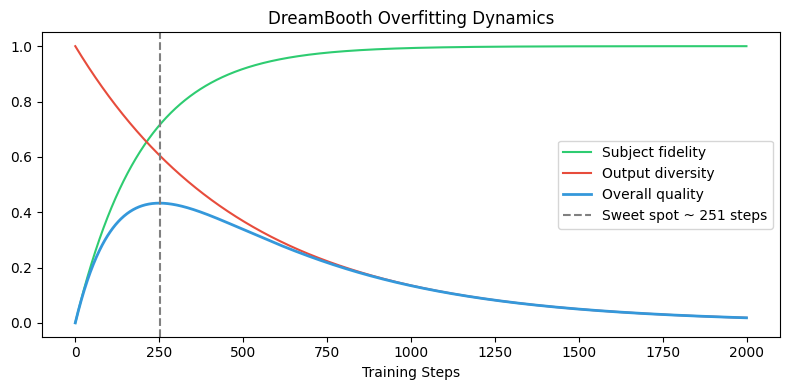

In [9]:
# Simulate DreamBooth overfitting curve
steps = np.arange(0, 2000)
subject_quality = 1 - np.exp(-steps / 200)  # Quickly learns subject
diversity = np.exp(-steps / 500)  # Slowly loses diversity
overall = subject_quality * diversity  # Sweet spot exists

plt.figure(figsize=(8, 4))
plt.plot(steps, subject_quality, label="Subject fidelity", color="#2ecc71")
plt.plot(steps, diversity, label="Output diversity", color="#e74c3c")
plt.plot(steps, overall, label="Overall quality", color="#3498db", linewidth=2)
optimal = steps[np.argmax(overall)]
plt.axvline(optimal, color="gray", linestyle="--", label=f"Sweet spot ~ {optimal} steps")
plt.xlabel("Training Steps")
plt.legend()
plt.title("DreamBooth Overfitting Dynamics")
plt.tight_layout()
plt.show()

In [10]:
info_box(
    "DreamBooth 之良策：<br>"
    "（一）用<b>先验保留损失</b>以防灾难性遗忘<br>"
    "（二）3 至 5 张图像训 <b>400 至 800 步</b><br>"
    "（三）用 <b>LoRA-DreamBooth</b> 以降过拟合之险",
    title="DreamBooth 之良策"
)


## 五、数据管道之工

生产级微调中，**数据之质重于量**。千张高质量、标注精良之图像，胜于十万张嘈杂之数据。

管道之要步：

1. **数据收集**：品质筛选、去重
2. **生成标题**：BLIP / LLaVA 自动标题，继以人工审阅
3. **分桶**：依宽高比分组（切勿随机裁剪！）
4. **预处理**：居中裁剪为备选，分辨率归一

In [11]:
def create_aspect_ratio_buckets(resolutions, target_pixels=512*512):
    """Group images by aspect ratio for efficient batching."""
    buckets = {}
    for w, h in resolutions:
        ratio = round(w / h, 1)
        # Find closest bucket resolution with ~target_pixels
        scale = math.sqrt(target_pixels / (w * h))
        bucket_w = round(w * scale / 64) * 64  # Round to multiple of 64
        bucket_h = round(h * scale / 64) * 64
        key = (bucket_w, bucket_h)
        buckets.setdefault(key, []).append((w, h))
    return buckets

# Demo
resolutions = [(1920, 1080), (1080, 1920), (1024, 1024), (800, 600), (600, 800)]
buckets = create_aspect_ratio_buckets(resolutions)
for bucket, images in buckets.items():
    print(f"Bucket {bucket[0]}x{bucket[1]}: {len(images)} images")

Bucket 704x384: 1 images
Bucket 384x704: 1 images
Bucket 512x512: 1 images
Bucket 576x448: 1 images
Bucket 448x576: 1 images


In [12]:
info_box(
    "随机裁剪毁构图。宽高比分桶乃高质量微调之必须 —— "
    "此即 SDXL 构图优于 SD v1 之缘故。",
    title="分桶何以为要"
)


## 六、常见故障模式

微调可以特定而可诊断之方式出错。此诊断表为汝之调试参考：

| 症状 | 可能原因 | 修复 |
|---------|-------------|-----|
| 色偏 | 学习率过高 / VAE 未冻结 | 学习率降至 1e-5，冻结 VAE |
| 模式坍缩 | 过拟合 | 减步数、增数据、用 LoRA |
| 输出模糊 | 训练不足 | 增步数，查损失曲线 |
| 构图不当 | 随机裁剪 | 用宽高比分桶 |
| 伪影 | 训练数据不良 | 清洗数据集，去水印 |
| 多样性丧失 | 过拟合（步数过多） | 减步数，增数据集，加正则化 |
| 文本不匹配 | 文本编码器未纳入（或不当纳入） | 依目标决定是否微调 CLIP |
| 风格未迁移 | LoRA 秩过低，或目标层不对 | 增秩，确保注意力层纳入 |

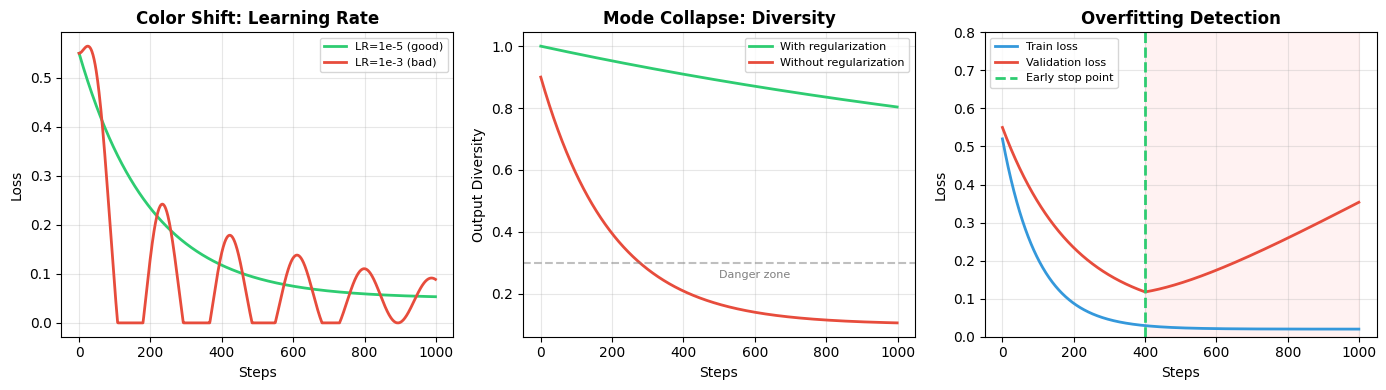

In [13]:
# Visualize common failure modes
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# 1. Color shift: LR too high
np.random.seed(42)
steps_range = np.arange(0, 1000)
good_lr = 0.5 * np.exp(-steps_range / 200) + 0.05
bad_lr = 0.5 * np.exp(-steps_range / 50) + 0.05 + 0.3 * np.sin(steps_range / 30) * np.exp(-steps_range / 500)

axes[0].plot(steps_range, good_lr, label="LR=1e-5 (good)", color="#2ecc71", lw=2)
axes[0].plot(steps_range, np.clip(bad_lr, 0, 1.5), label="LR=1e-3 (bad)", color="#e74c3c", lw=2)
axes[0].set_title("Color Shift: Learning Rate", fontweight="bold")
axes[0].set_xlabel("Steps")
axes[0].set_ylabel("Loss")
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# 2. Mode collapse
diversity_good = np.exp(-steps_range / 2000) * 0.5 + 0.5
diversity_bad = np.exp(-steps_range / 200) * 0.8 + 0.1

axes[1].plot(steps_range, diversity_good, label="With regularization", color="#2ecc71", lw=2)
axes[1].plot(steps_range, diversity_bad, label="Without regularization", color="#e74c3c", lw=2)
axes[1].axhline(y=0.3, color="gray", linestyle="--", alpha=0.5)
axes[1].text(500, 0.25, "Danger zone", color="gray", fontsize=8)
axes[1].set_title("Mode Collapse: Diversity", fontweight="bold")
axes[1].set_xlabel("Steps")
axes[1].set_ylabel("Output Diversity")
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

# 3. Overfitting vs underfitting
train_loss = 0.5 * np.exp(-steps_range / 100) + 0.02
val_loss = 0.5 * np.exp(-steps_range / 200) + 0.05
val_loss[400:] += np.linspace(0, 0.3, len(steps_range) - 400)

axes[2].plot(steps_range, train_loss, label="Train loss", color="#3498db", lw=2)
axes[2].plot(steps_range, val_loss, label="Validation loss", color="#e74c3c", lw=2)
axes[2].axvline(x=400, color="#2ecc71", linestyle="--", lw=2, label="Early stop point")
axes[2].fill_between(steps_range[400:], 0, 1, alpha=0.05, color="red")
axes[2].set_title("Overfitting Detection", fontweight="bold")
axes[2].set_xlabel("Steps")
axes[2].set_ylabel("Loss")
axes[2].legend(fontsize=8)
axes[2].grid(True, alpha=0.3)
axes[2].set_ylim(0, 0.8)

plt.tight_layout()
plt.show()

In [14]:
info_box(
    "调试之第一利器：于不同训练检查点以同一提示生成图像。"
    "过拟合抑或训练不足，一目了然。",
    title="调试之诀"
)


## 七、总括与延伸阅读

### 何时用何法

| 方法 | 适用 | 所需数据 | 训练代价 | 风险 |
|--------|----------|-------------|---------------|------|
| **ControlNet** | 空间控制（边缘、姿态、深度） | 5 万至 50 万对 | 10-50 GPU 时 | 低（基础冻结） |
| **LoRA** | 风格迁移、概念适配 | 100 至 1 万图 | 2-10 GPU 时 | 低至中 |
| **DreamBooth** | 个性化（特定主体） | 3 至 20 图 | 0.5-2 GPU 时 | 高（过拟合） |

### 要旨

1. **ControlNet** 增空间条件而不触基础模型 —— 零卷积为关键之巧
2. **LoRA** 以不及百分之一之参数达近乎全量微调之品质
3. **DreamBooth** 以仅 3 至 5 张图像个性化，然须谨慎之早停
4. **数据管道**至关重要 —— 标题品质与宽高比分桶不可或缺
5. **故障模式**皆可诊断：习「症状-原因-修复」之模式

### 论文

- [Adding Conditional Control to Text-to-Image Diffusion Models](https://arxiv.org/abs/2302.05543) (ControlNet —— Zhang 等，2023)
- [LoRA: Low-Rank Adaptation of Large Language Models](https://arxiv.org/abs/2106.09685) (Hu 等，2021)
- [DreamBooth: Fine Tuning Text-to-Image Diffusion Models for Subject-Driven Generation](https://arxiv.org/abs/2208.12242) (Ruiz 等，2023)

**扩散模型系列至此圆满！**

微调模型之高效服务，参见 [推断优化](../../en/inference/) 系列。